# Network Science - UDD

## Práctico: Inferencia + evaluación + ética en redes


#### [*Cristian Candia-Castro Vallejos, Ph.D.*](https://crcandia.com)

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---

**Unidad 7:** Inferencia + evaluación + ética  
**Objetivos prácticos:**

1. aplicar un **rewiring / permutation test** a una estadística estructural;
2. demostrar con código un caso de **split malo vs split correcto** sin introducir tareas nuevas;
3. cerrar con un **checklist ético aplicado**.

En este notebook vamos a usar redes pequeñas y controladas para que la intuición quede limpia. La lógica metodológica luego se traslada a redes reales más grandes.


In [35]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score

rng = np.random.default_rng(42)
plt.rcParams['figure.figsize'] = (6, 4)


## Antes de empezar: qué vamos a validar

En este práctico vamos a validar cuatro ideas metodológicas concretas:

1. si una estructura aparente es más fuerte que un **modelo nulo** razonable
2. si una alineación entre atributo y estructura es más fuerte que **azar**
3. si un score predictivo mejora de verdad o si se infló por **leakage**
4. si el diseño completo sería defendible no solo metodológicamente, sino también **éticamente**

Ese orden importa: primero definimos la pregunta, después el contraste, y recién al final interpretamos.



## Parte A — Rewiring test para modularidad

Vamos a tomar la red de Karate Club, detectar comunidades con greedy modularity y luego comparar la modularidad observada contra una distribución nula obtenida por **degree-preserving rewiring**.

La pregunta correcta es:

> ¿La cohesión comunitaria observada es más alta que la esperable solo por secuencia de grados?


In [ ]:
# 1. Validar que la estructura aparente es más fuerte que un modelo nulo razonable
G = nx.karate_club_graph()
# Detectamos comunidades con el método de Louvain
communities = list(nx.algorithms.community.greedy_modularity_communities(G))
# Calculamos la modularidad observada
Q_obs = nx.algorithms.community.quality.modularity(G, communities)
len(communities), Q_obs


(3, 0.41096493693896297)

In [43]:
# Para validar que esta modularidad es realmente fuerte, podemos comparar contra un 
# modelo nulo que preserve la distribución de grados pero rewiree las conexiones al azar.
def degree_preserving_rewire(G, nswap_per_edge=10, seed=0):
    H = G.copy()
    m = H.number_of_edges()
    nswap = max(1, int(nswap_per_edge * m))
    try:
        nx.double_edge_swap(H, nswap=nswap, max_tries=nswap * 20, seed=seed)
        success = True
    except Exception:
        success = False
    return H, success

n_perm = 3000
Q_null = []
ok = 0

# Rewireamos la red varias veces y calculamos la modularidad de cada una
for i in range(n_perm):
    H, success = degree_preserving_rewire(G, nswap_per_edge=8, seed=int(i))
    ok += int(success)
    comm_H = list(nx.algorithms.community.greedy_modularity_communities(H))
    Q_null.append(nx.algorithms.community.quality.modularity(H, comm_H))

Q_null = np.array(Q_null)
print(f"Rewirings completados sin excepción: {ok}/{n_perm}")


Rewirings completados sin excepción: 3000/3000


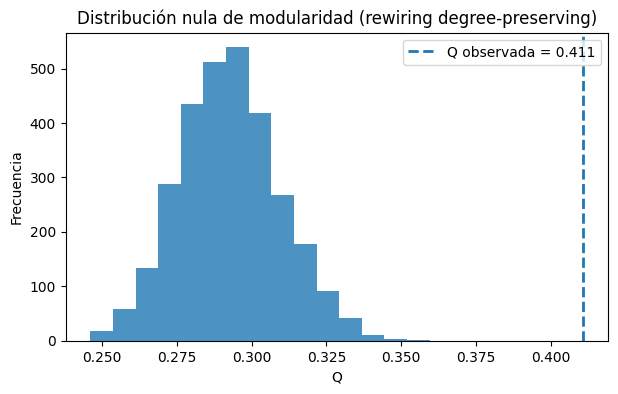

Q observada: 0.411
Media nulo: 0.293
p-valor empírico (cola derecha): < 0.001


In [44]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(Q_null, bins=15, alpha=0.8)
ax.axvline(Q_obs, linewidth=2, linestyle='--', label=f'Q observada = {Q_obs:.3f}')
ax.set_title('Distribución nula de modularidad (rewiring degree-preserving)')
ax.set_xlabel('Q')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.show()


# p-valor empírico de cola derecha:
# proporción de redes nulas con modularidad >= a la observada,
# usando corrección +1 para evitar p = 0 en Monte Carlo finito
p_emp = (np.sum(Q_null >= Q_obs) + 1) / (len(Q_null) + 1)

print(f"Q observada: {Q_obs:.3f}")
print(f"Media nulo: {Q_null.mean():.3f}")
print("p-valor empírico (cola derecha):", "< 0.001" if p_emp < 0.001 else f"{p_emp:.3f}")

### Lectura correcta

- Si $Q_{obs}$ cae claramente a la derecha de la distribución nula, eso sugiere que la partición observada tiene más estructura mesoscópica que la esperable por grado solo.
- Ojo: esto **no** implica que la partición sea única, ni que represente “comunidades verdaderas” en sentido sustantivo.
- Tampoco elimina otros problemas clásicos: límite de resolución, degeneración de soluciones, sensibilidad a semillas o a representación.

**Caveat metodológico importante:** este rewiring es razonable para docencia, pero no garantiza muestreo uniforme exacto de todas las redes con la misma secuencia de grados.  

Por eso, la interpretación correcta es: **evidencia respecto de este nulo operativo**, no prueba definitiva de una estructura “real”.



## Parte B — Permutation test para concentración de atributos

Ahora fijamos la red y preguntamos si el atributo `club` (Mr. Hi vs Officer) está más alineado con la estructura de lo esperable al azar.

Usaremos como estadística la **fracción de aristas intra-grupo**.


In [45]:
# Atributo nodal: facción a la que pertenece cada miembro del club
# En esta red, el atributo "club" toma valores como "Mr. Hi" u "Officer"
club = {n: G.nodes[n]["club"] for n in G.nodes()}

# ------------------------------------------------------------
# Función de interés:
# proporción de aristas que conectan nodos con el mismo atributo
# ------------------------------------------------------------
def within_group_edge_fraction(G, labels):
    """
    Calcula la fracción de aristas cuyos extremos comparten el mismo label.

    Parámetros
    ----------
    G : networkx.Graph
        Red observada.
    labels : dict
        Diccionario {nodo: atributo}.

    Retorna
    -------
    float
        Fracción de aristas dentro del mismo grupo.
    """
    same = sum(1 for u, v in G.edges() if labels[u] == labels[v])
    return same / G.number_of_edges()


# ------------------------------------------------------------
# Estadística observada
# ------------------------------------------------------------
# ¿Qué tan alineado está el atributo "club" con la estructura de la red?
# Si muchas aristas conectan nodos del mismo club, la fracción será alta.
frac_obs = within_group_edge_fraction(G, club)


# ------------------------------------------------------------
# Nulo por permutación:
# mantenemos fija la red y reasignamos aleatoriamente el atributo
# ------------------------------------------------------------
# La idea es romper la alineación entre estructura y atributo,
# pero sin cambiar la topología de la red.
nodes = list(G.nodes())
orig_labels = [club[n] for n in nodes]

frac_null = []

# Usamos muchas permutaciones para aproximar la distribución nula
for _ in range(2000):
    # Reasignamos aleatoriamente los labels a los mismos nodos
    permuted = rng.permutation(orig_labels)
    labels_perm = dict(zip(nodes, permuted))

    # Recalculamos la misma estadística bajo esta reasignación aleatoria
    frac_null.append(within_group_edge_fraction(G, labels_perm))

frac_null = np.array(frac_null)


# ------------------------------------------------------------
# p-valor empírico de cola derecha
# ------------------------------------------------------------
# Pregunta: ¿qué tan extremo es frac_obs comparado con lo que esperaríamos
# si el atributo estuviera asignado al azar sobre esta misma red?
p_value_frac = (np.sum(frac_null >= frac_obs) + 1) / (len(frac_null) + 1)


# ------------------------------------------------------------
# Resumen numérico
# ------------------------------------------------------------
print(f"Fracción observada de aristas intra-grupo: {frac_obs:.3f}")
print(f"Media nula: {frac_null.mean():.3f}")
print(f"Desv. estándar nula: {frac_null.std():.3f}")
print("p-valor empírico (cola derecha):", "< 0.001" if p_value_frac < 0.001 else f"{p_value_frac:.3f}")

Fracción observada de aristas intra-grupo: 0.859
Media nula: 0.487
Desv. estándar nula: 0.049
p-valor empírico (cola derecha): < 0.001


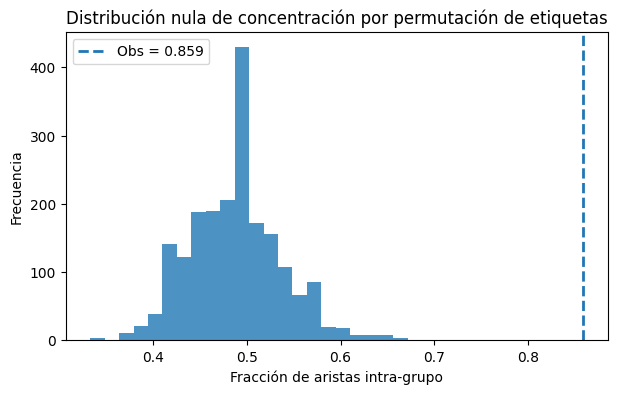

In [46]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(frac_null, bins=25, alpha=0.8)
ax.axvline(frac_obs, linewidth=2, linestyle='--', label=f'Obs = {frac_obs:.3f}')
ax.set_title('Distribución nula de concentración por permutación de etiquetas')
ax.set_xlabel('Fracción de aristas intra-grupo')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.show()


## Idea metodológica

Acá **no estamos permutando la red**.
La red queda tal como está. Lo único que cambiamos es **quién tiene qué atributo**.

Entonces la pregunta del test es:

> **Si esta misma red tuviera los atributos repartidos al azar, ¿veríamos una concentración tan alta como la observada?**

Si la respuesta es no, eso sugiere que la relación entre atributo y estructura **no parece explicarse solo por azar**.

Ojo: eso **no prueba automáticamente un mecanismo** como influencia o selección.
Pero sí muestra que la alineación observada entre estructura y atributo es más fuerte que la esperable bajo este nulo.

---


## Parte C — Split ingenuo vs evaluación más exigente en una tarea sobre nodos

> Queremos inferir un **atributo nodal** y comparar dos diseños de evaluación.

Usaremos varias redes sintéticas de cursos, cada una con dos bloques y un atributo binario parcialmente alineado con la estructura.

La tarea es la misma en ambos casos:
**predecir el atributo de nodos no observados.**

Compararemos:

1. **Split ingenuo**: partir nodos al azar dentro del mismo curso.
2. **Evaluación más exigente**: usar solo una semilla más pequeña de nodos observados y evaluar en el resto.

La tarea no cambia.
Lo que cambia es **cuánta estructura comparten train y test** y, por tanto, **qué tipo de generalización estamos evaluando**.



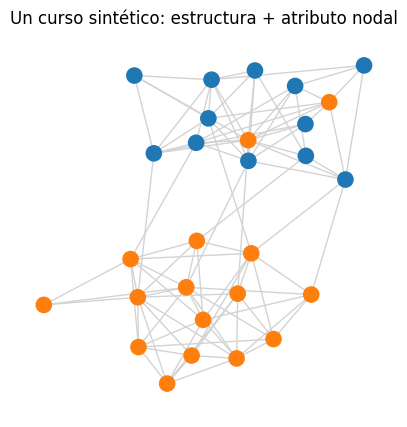

In [ ]:
def make_course(seed, p_in):
    # Creamos una red sintética con dos grupos de 14 nodos cada uno, con p_in de conexión intra-grupo y p_out de conexión inter-grupo
    G = nx.planted_partition_graph(l=2, k=14, p_in=p_in, p_out=0.02, seed=seed)
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    y = {}
    for n in G.nodes():
        block = 0 if n < 14 else 1
        flip = np.random.default_rng(seed + n).random() < 0.15
        y[n] = block if not flip else 1 - block
    return G, y

# Creamos varios cursos sintéticos con diferentes niveles de alineación entre estructura y atributo
# 5 cursos, con p_in decrecientes para reducir la alineación
courses = [make_course(seed=s, p_in=p) for s, p in zip([1,2,3,4,5], [0.48, 0.43, 0.39, 0.35, 0.30])]

# Visualizamos uno de los cursos
G_demo, y_demo = courses[0]
pos = nx.spring_layout(G_demo, seed=4)
node_colors = ['tab:orange' if y_demo[n] == 1 else 'tab:blue' for n in G_demo.nodes()]

fig, ax = plt.subplots(figsize=(5,5))
nx.draw_networkx(G_demo, pos=pos, node_color=node_colors, node_size=120,
                 edge_color='lightgray', with_labels=False, ax=ax)
ax.set_title('Un curso sintético: estructura + atributo nodal')
ax.axis('off')
plt.show()


In [ ]:
def simple_neighbor_vote_accuracy(G, y, train_nodes, test_nodes):
    """
    Predice el atributo de cada nodo de test usando el voto mayoritario
    de sus vecinos que sí están observados en train_nodes.

    Parámetros
    ----------
    G : networkx.Graph
        Red del curso.
    y : dict
        Diccionario {nodo: clase}.
    train_nodes : list o set
        Nodos cuyos atributos asumimos observados.
    test_nodes : list o set
        Nodos sobre los que evaluamos predicción.

    Retorna
    -------
    float
        Accuracy promedio en test.
    """
    train_nodes = set(train_nodes)
    preds, true = [], []

    for n in test_nodes:
        # Vecinos del nodo n cuyos atributos sí conocemos (porque están en train)
        neigh = [v for v in G.neighbors(n) if v in train_nodes]

        if len(neigh) == 0:
            # Si n no tiene vecinos observados en train,
            # usamos como predicción la clase más frecuente en train.
            pred = Counter(y[v] for v in train_nodes).most_common(1)[0][0]
        else:
            # Si sí tiene vecinos observados, usamos voto mayoritario local.
            pred = Counter(y[v] for v in neigh).most_common(1)[0][0]

        preds.append(pred)
        true.append(y[n])

    return np.mean(np.array(preds) == np.array(true))


#Split malo: nodos aleatorios dentro de cada curso

acc_bad = []

for idx, (G, y) in enumerate(courses):
    # Mezclamos nodos del mismo curso al azar.
    # Eso hace que train y test sigan viviendo en la misma red
    # y compartan vecindarios, comunidades y contexto local.
    nodes = list(G.nodes())
    rng = np.random.default_rng(100 + idx)
    rng.shuffle(nodes)

    cut = int(0.7 * len(nodes))
    train_nodes, test_nodes = nodes[:cut], nodes[cut:]

    acc_bad.append(simple_neighbor_vote_accuracy(G, y, train_nodes, test_nodes))


# Evaluación más honesta: contexto nuevo dentro del curso
acc_good = []

for idx, (G, y) in enumerate(courses):
    nodes = list(G.nodes())
    rng = np.random.default_rng(200 + idx)
    rng.shuffle(nodes)

    cut = int(0.3 * len(nodes)) # Solo el 30% de los nodos se usan como semilla observada
    seed_nodes, test_nodes = nodes[:cut], nodes[cut:]

    # Aquí simulamos un escenario más exigente:
    # solo conocemos un pequeño conjunto semilla de nodos observados
    # y debemos predecir el resto a partir de esa información parcial.
    acc_good.append(simple_neighbor_vote_accuracy(G, y, seed_nodes, test_nodes))


pd.DataFrame({
    'curso': np.arange(1, len(courses)+1),
    'split_malo_nodos_mezclados': np.round(acc_bad, 3),
    'evaluacion_mas_exigente_observacion_parcial': np.round(acc_good, 3)
})

,curso,split_malo_nodos_mezclados,evaluacion_mas_exigente_observacion_parcial
0,1,1.000,0.75
1,2,1.000,0.65
2,3,1.000,0.80
3,4,1.000,0.75
4,5,0.889,0.65


### Idea metodológica

Este ejemplo ilustra que, en redes, la evaluación depende fuertemente de cuánto comparten estructuralmente train y test.

- Si mezclamos nodos al azar dentro de la misma red, el predictor puede beneficiarse de vecinos observados muy cercanos al nodo de test.
- Si reducimos la observación disponible y exigimos predecir desde una semilla más pequeña (30% en este caso), ese beneficio disminuye.

Por eso, un buen desempeño en un split aleatorio de nodos no necesariamente indica verdadera capacidad de generalización.  
Puede reflejar, al menos en parte, que train y test siguen demasiado entrelazados en la misma estructura.


### Cómo leer este ejemplo

Usamos un predictor muy simple: asignar a cada nodo la clase mayoritaria entre sus vecinos observados.

La comparación importante no es entre modelos distintos, sino entre dos diseños de evaluación:

- **Split aleatorio de nodos dentro del curso:** train y test siguen muy mezclados en la misma red, por lo que el predictor puede aprovechar vecindarios compartidos.
- **Observación parcial más exigente:** solo observamos una semilla pequeña del curso y tratamos de inferir el resto. Esto reduce el acceso a vecinos observados y hace más difícil la tarea.

Si el desempeño cae en el segundo caso, eso sugiere que parte del rendimiento del primer split venía de estructura compartida entre train y test, no necesariamente de una capacidad fuerte de generalización.

Ojo: este segundo esquema es más exigente, pero todavía ocurre dentro del mismo curso. Una validación realmente fuera de contexto requeriría separar cursos completos o usar un diseño temporal/institucional alineado con el escenario real de uso.

### Comparación agregada

No interpretes esto como “el segundo diseño es el único correcto en todo problema”.  
Interprétalo así:

- el primero responde una pregunta **más local y más fácil**;
- el segundo se acerca más a una pregunta de **generalización a contexto nuevo**.

Si en tu conclusión hablas de “usar esto en un curso nuevo”, no deberías validar solo con nodos mezclados dentro del mismo curso.


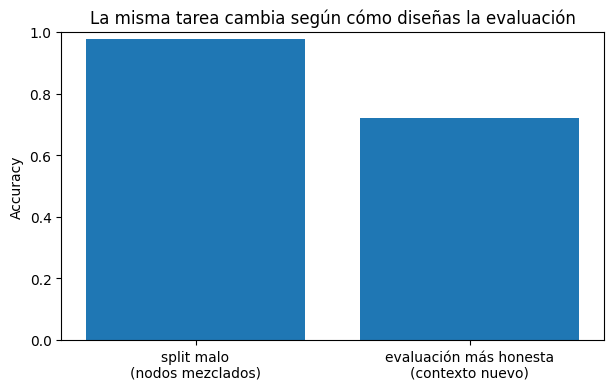

Accuracy promedio split malo: 0.978
Accuracy promedio evaluación más honesta: 0.720


In [33]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(['split malo\n(nodos mezclados)', 'evaluación más honesta\n(contexto nuevo)'],
       [np.mean(acc_bad), np.mean(acc_good)])
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('La misma tarea cambia según cómo diseñas la evaluación')
plt.show()

print(f'Accuracy promedio split malo: {np.mean(acc_bad):.3f}')
print(f'Accuracy promedio evaluación más honesta: {np.mean(acc_good):.3f}')


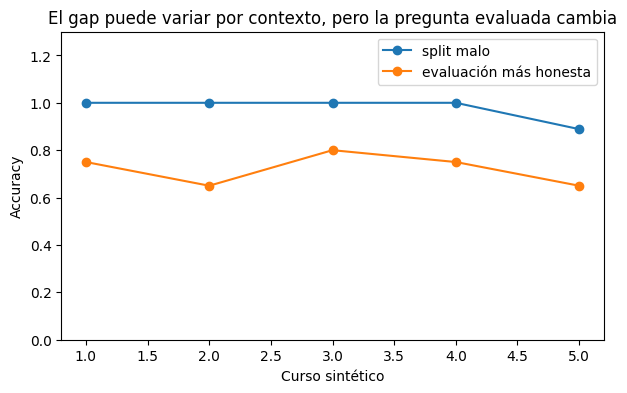

In [34]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(np.arange(1, len(courses)+1), acc_bad, marker='o', label='split malo')
ax.plot(np.arange(1, len(courses)+1), acc_good, marker='o', label='evaluación más honesta')
ax.set_xlabel('Curso sintético')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.3)
ax.set_title('El gap puede variar por contexto, pero la pregunta evaluada cambia')
ax.legend()
plt.show()


### Interpretación

El punto no es el predictor, que aquí es muy simple.  
El punto es metodológico.

- **Nodos mezclados dentro de la misma red**: test comparte el mismo contexto relacional con train.
- **Contexto nuevo**: la evaluación se acerca más a una situación donde quieres usar la lógica en una red que no es exactamente la misma.

Entonces, antes de reportar desempeño, siempre pregunta:

1. ¿qué unidad estoy prediciendo?
2. ¿quiero generalizar dentro de esta misma red o a una red nueva?
3. ¿mi split refleja ese uso final?

Ese es exactamente el tipo de cuidado que evita leakage y sobreclaim en ciencia de redes aplicada.


---


## Parte D — Bonus corto: cuándo random split por nodo no responde la pregunta correcta

En node classification, un split aleatorio dentro del mismo grafo puede ser razonable si tu pregunta es **imputar labels faltantes en esta misma red**.

Pero si tu aplicación real es generalizar a:

- nuevos cursos,
- nuevas escuelas,
- nuevas comunidades,
- nuevos periodos,

entonces ese random split puede dar una imagen demasiado optimista. Ahí conviene pensar en:

- **group split**,
- **leave-one-graph-out**,
- **time split**,
- etc.



## Parte E — Checklist ético aplicado

Supón que quieres modelar una red de interacción entre estudiantes para detectar aislamiento, victimización o riesgo psicosocial.

### Preguntas mínimas antes de modelar

1. **¿La red observada corresponde realmente a interacción social o es solo un proxy?**  
   Ejemplo: co-presencia por WiFi no equivale automáticamente a vínculo social.

2. **¿Un estudiante puede quedar expuesto por las nominaciones de otros aunque él no haya consentido?**

3. **¿La visualización del grafo podría reidentificar casos sensibles aunque ocultes los nombres?**

4. **¿El modelo podría amplificar estigmas si predice “riesgo” sobre nodos periféricos o minoritarios?**

5. **¿La intervención derivada del modelo tiene costo asimétrico?**  
   Un falso positivo y un falso negativo no dañan igual.

### Regla práctica

Si la aplicación toca salud mental, bullying, sexualidad, persecución política, datos escolares o redes pequeñas fácilmente reconocibles, el estándar ético debe subir mucho.



## Cierre

Este notebook mostró tres ideas clave:

- **una estadística estructural necesita compararse contra un nulo relevante**;
- **un desempeño predictivo puede inflarse por leakage topológico**;
- **en redes, la ética no se resuelve solo quitando nombres**.

La lógica correcta para tus análisis futuros debería ser:

> representación explícita → split alineado con la tarea → métrica adecuada → contraste contra nulo → reporte de límites y riesgos.
